# TPMAQ2 — Parte 2: XGBoost, CatBoost y comparación final

Continuación de `TPMAQ2_VML_mlflow_parte1.ipynb` (que ahora incluye Baseline, KNN, SVM
**y Random Forest**). Este notebook vuelve a cargar los datos desde cero (no depende de
ninguna variable de la Parte 1) y corre XGBoost y CatBoost en un kernel nuevo, con toda
la RAM libre — separados de Random Forest para descartar cualquier residuo de memoria
entre secciones.

**Prerequisito:** haber corrido la Parte 1 al menos una vez, y que el archivo `mlflow.db`
generado por esa corrida esté en la **misma carpeta** que este notebook — la comparación
final y el registro del champion consultan a MLflow para traer las métricas de los cinco
modelos de la Parte 1, en vez de depender de variables de Python que ya no existen en
este kernel.


In [1]:
# ── Carga de datos procesados desde TPMAQ1 ───────────────────────────────────
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    classification_report, confusion_matrix,
    accuracy_score, f1_score, precision_score, recall_score
)
import time
import warnings
warnings.filterwarnings('ignore')

DATA_DIR = '../EDA/dataset/'

X_train = pd.read_csv(DATA_DIR + 'X_train.csv', index_col=0)
X_test  = pd.read_csv(DATA_DIR + 'X_test.csv',  index_col=0)
y_train = pd.read_csv(DATA_DIR + 'y_train.csv', index_col=0).squeeze()
y_test  = pd.read_csv(DATA_DIR + 'y_test.csv',  index_col=0).squeeze()

# Columnas OHE pueden quedar con NaN en pandas moderno cuando hay missing en la
# variable original. Para esas columnas el valor correcto es 0 (no pertenece a esa categoría).
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)

print('Datos cargados correctamente:')
print(f'  X_train: {X_train.shape}')
print(f'  X_test : {X_test.shape}')
print(f'  y_train: {y_train.shape} | clases: {y_train.value_counts().to_dict()}')
print(f'  y_test : {y_test.shape}  | clases: {y_test.value_counts().to_dict()}')
print(f'  NaN en X_train: {X_train.isna().sum().sum()} — NaN en X_test: {X_test.isna().sum().sum()}')
print(f'\nTipos de datos:')
print(X_train.dtypes)


Datos cargados correctamente:
  X_train: (2275322, 19)
  X_test : (975139, 19)
  y_train: (2275322,) | clases: {'Mediano': 1266151, 'Corto': 596958, 'Largo': 412213}
  y_test : (975139,)  | clases: {'Mediano': 542636, 'Corto': 255840, 'Largo': 176663}
  NaN en X_train: 0 — NaN en X_test: 0

Tipos de datos:
hora_sin                float64
hora_cos                float64
mes_sin                 float64
mes_cos                 float64
es_fin_de_semana          int64
lat_estacion_origen     float64
long_estacion_origen    float64
modelo_bicicleta          int64
genero_MALE               int64
genero_OTHER              int64
dia_semana_Monday         int64
dia_semana_Saturday       int64
dia_semana_Sunday         int64
dia_semana_Thursday       int64
dia_semana_Tuesday        int64
dia_semana_Wednesday      int64
turno_mañana              int64
turno_noche               int64
turno_tarde               int64
dtype: object


In [2]:
# Limpieza global: garantiza que X_train y X_test no tengan NaN
# sin importar la versión de pandas que generó los CSVs
X_train = X_train.fillna(0)
X_test  = X_test.fillna(0)
print(f'NaN en X_train: {X_train.isna().sum().sum()} | NaN en X_test: {X_test.isna().sum().sum()}')


NaN en X_train: 0 | NaN en X_test: 0


In [3]:
import os, matplotlib.pyplot as plt

PNG_DIR = 'Png'
os.makedirs(PNG_DIR, exist_ok=True)
print(f'Figuras se guardarán en: {os.path.abspath(PNG_DIR)}')

Auto-guardado de figuras activo → carpeta: /Users/FedericoFernandez/Desktop/CEIA-APRENDIZAJE_DE_MAQUINA-TP-FINAL-main/Entrega_Aprendizaje_Maq/Png


In [ ]:
# ── Setup de MLflow para tracking del experimento ────────────────────────────
!pip install mlflow -q

import mlflow

MLFLOW_DB_PATH = 'mlflow.db'
mlflow.set_tracking_uri(f'sqlite:///{MLFLOW_DB_PATH}')

EXPERIMENT_NAME = 'TPMAQ2_Ecobici_Duracion_v2'
mlflow.set_experiment(EXPERIMENT_NAME)


def make_mlflow_optuna_callback(metric_name='f1_macro_cv'):
    """Crea un callback de Optuna que loguea cada trial como un run anidado en MLflow."""
    def _callback(study, trial):
        with mlflow.start_run(run_name=f'trial_{trial.number}', nested=True):
            mlflow.log_params(trial.params)
            mlflow.log_metric(metric_name, trial.value)
    return _callback


def log_final_metrics(acc, f1_macro, f1_weighted, prec_macro, rec_macro,
                       f1_per_class=None, prec_per_class=None, rec_per_class=None,
                       class_order=None, fit_time=None, pred_time=None):
    """Loguea métricas globales, por clase y tiempos en el run activo de MLflow."""
    metrics = {
        'accuracy': acc,
        'f1_macro': f1_macro,
        'f1_weighted': f1_weighted,
        'precision_macro': prec_macro,
        'recall_macro': rec_macro,
    }
    if fit_time is not None:
        metrics['fit_time_seg'] = fit_time
    if pred_time is not None:
        metrics['pred_time_seg'] = pred_time
    if f1_per_class is not None and class_order is not None:
        for clase, f1_c, prec_c, rec_c in zip(class_order, f1_per_class, prec_per_class, rec_per_class):
            clase_key = clase.lower()
            metrics[f'f1_{clase_key}']        = float(f1_c)
            metrics[f'precision_{clase_key}'] = float(prec_c)
            metrics[f'recall_{clase_key}']    = float(rec_c)
    mlflow.log_metrics(metrics)


print(f'MLflow tracking URI : {mlflow.get_tracking_uri()}')
print(f'Experimento activo  : {EXPERIMENT_NAME}')
print('Para ver la UI, corré en una terminal en este mismo directorio:')
print(f'  mlflow ui --backend-store-uri sqlite:///{MLFLOW_DB_PATH}')


# ── Limpieza de memoria entre secciones ──────────────────────────────────────
import gc


def free_memory(*names):
    """Borra de la sesión las variables pasadas por nombre (si existen) y libera memoria.
    Pensado para correr al final de cada sección de modelo, una vez que sus
    métricas/artifacts/modelo ya fueron logueados en MLflow y esos datasets
    de muestra ya no hacen falta para el resto del notebook."""
    g = globals()
    freed = []
    for name in names:
        if name in g:
            del g[name]
            freed.append(name)
    gc.collect()
    if freed:
        print(f'[Memoria] Liberado: {", ".join(freed)}')
    else:
        print('[Memoria] Nada para liberar (¿ya se había limpiado antes?)')


In [ ]:
# ── Imports que en el notebook original se hacían en la sección de KNN ──────
# (Optuna y cross_val_score se usan acá en RF/XGBoost, pero en la Parte 1
# estaban importados junto con KNN — como la Parte 2 no corre esa sección,
# hay que traerlos de nuevo)
!pip install optuna -q

import optuna
from sklearn.model_selection import cross_val_score

print("Imports Optuna + cross_val_score OK")


---
## 18. Modelo XGBoost — Búsqueda de hiperparámetros con Optuna

**XGBoost** (Extreme Gradient Boosting) es un método de ensamble basado en **Boosting**:
a diferencia de Random Forest que entrena árboles en paralelo e independientes,
XGBoost los entrena **secuencialmente** — cada árbol nuevo se enfoca en corregir
los errores del árbol anterior.

**Diferencia clave con Random Forest (Bagging vs Boosting):**

| | Random Forest (Bagging) | XGBoost (Boosting) |
|---|---|---|
| Árboles | Paralelos e independientes | Secuenciales, cada uno corrige al anterior |
| Objetivo | Reducir varianza | Reducir sesgo |
| Velocidad de entrenamiento | Paralelizable | Secuencial (más lento) |
| Riesgo | Robusto por default | Puede overfittear sin regularización |

XGBoost agrega regularización L1 y L2 nativa, poda de árboles y manejo eficiente
de valores faltantes, lo que lo convierte en uno de los algoritmos más potentes
para datos tabulares.

**Hiperparámetros optimizados con Optuna:**
- `n_estimators`: cantidad de árboles en la secuencia.
- `max_depth`: profundidad máxima de cada árbol.
- `learning_rate`: tasa de aprendizaje — cuánto corrige cada árbol nuevo.
- `subsample`: fracción de filas usadas en cada árbol — reduce overfitting.
- `colsample_bytree`: fracción de features usadas en cada árbol — similar a `max_features` en RF.
- `gamma`: penalización por hacer un split — controla la complejidad del árbol.
- `reg_alpha`: regularización L1.
- `reg_lambda`: regularización L2.

**Muestra de entrenamiento:** igual que Random Forest — 300k para búsqueda, 500k para entrenamiento final.

**Métrica de optimización:** F1-macro.

In [35]:
!pip install xgboost -q

import xgboost as xgb
from sklearn.preprocessing import LabelEncoder

print('Imports XGBoost OK')


[notice] A new release of pip is available: 26.0.1 -> 26.1.2
[notice] To update, run: pip install --upgrade pip
Imports XGBoost OK


In [36]:
#  XGBoost requiere target numérico
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

le_target = LabelEncoder()
le_target.fit(CLASS_ORDER)

y_train_enc = le_target.transform(y_train)
y_test_enc  = le_target.transform(y_test)

print('Mapping de clases:', dict(zip(CLASS_ORDER, le_target.transform(CLASS_ORDER))))

Mapping de clases: {'Corto': np.int64(0), 'Mediano': np.int64(2), 'Largo': np.int64(1)}


In [37]:
# Muestras estratificadas
SAMPLE_SEARCH = 200_000
SAMPLE_TRAIN  = 1_500_000
RANDOM_STATE  = 42

X_xgb_search, _, y_xgb_search, _ = train_test_split(
    X_train, y_train_enc,
    train_size=SAMPLE_SEARCH,
    stratify=y_train_enc,
    random_state=RANDOM_STATE,
)

X_xgb_search = X_xgb_search.fillna(0)

X_xgb_train, _, y_xgb_train, _ = train_test_split(
    X_train, y_train_enc,
    train_size=SAMPLE_TRAIN,
    stratify=y_train_enc,
    random_state=RANDOM_STATE,
)

print(f'Muestra búsqueda : {X_xgb_search.shape[0]:,} filas')
print(f'Muestra train    : {X_xgb_train.shape[0]:,} filas')

Muestra búsqueda : 500,000 filas
Muestra train    : 1,500,000 filas


In [ ]:
# ── MLflow: inicio de run — XGBoost (con nested runs de Optuna) ─────────────
mlflow.start_run(run_name='XGBoost_Optuna')
mlflow.set_tags({'modelo': 'XGBClassifier', 'categoria': 'ml_optuna'})

mlflow_cb_xgb = make_mlflow_optuna_callback()


In [38]:
# Función objetivo para Optuna
def objective_xgb(trial):
    params = {
        'n_estimators'     : trial.suggest_int('n_estimators', 100, 300),
        'max_depth'        : trial.suggest_int('max_depth', 3, 10),
        'learning_rate'    : trial.suggest_float('learning_rate', 0.01, 0.3, log=True),
        'subsample'        : trial.suggest_float('subsample', 0.5, 1.0),
        'colsample_bytree' : trial.suggest_float('colsample_bytree', 0.5, 1.0),
        'gamma'            : trial.suggest_float('gamma', 0, 5),
        'reg_alpha'        : trial.suggest_float('reg_alpha', 0, 2),
        'reg_lambda'       : trial.suggest_float('reg_lambda', 0, 2),
    }

    model = xgb.XGBClassifier(
        **params,
        objective='multi:softmax',
        num_class=3,
        eval_metric='mlogloss',
        use_label_encoder=False,
        random_state=RANDOM_STATE,
        n_jobs=-1,
        verbosity=0,
    )

    scores = cross_val_score(model, X_xgb_search, y_xgb_search, cv=3, scoring='f1_macro', n_jobs=1)
    return scores.mean()


def champion_callback_xgb(study, frozen_trial):
    winner = study.user_attrs.get('winner', None)
    if study.best_value and winner != study.best_value:
        study.set_user_attr('winner', study.best_value)
        if winner:
            improvement = (abs(winner - study.best_value) / study.best_value) * 100
            print(f'Trial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f} '
                  f'(mejora: {improvement:.4f}%)')
        else:
            print(f'Trial inicial {frozen_trial.number} — F1-macro: {frozen_trial.value:.4f}')

In [39]:
# Ejecutar búsqueda con Optuna (5 min aprox)
optuna.logging.set_verbosity(optuna.logging.ERROR)

study_xgb = optuna.create_study(direction='maximize')
study_xgb.optimize(objective_xgb, n_trials=25, callbacks=[champion_callback_xgb, mlflow_cb_xgb])

print(f'\nMejores hiperparámetros encontrados:')
for k, v in study_xgb.best_params.items():
    print(f'  {k:<22}: {v}')
print(f'\nMejor F1-macro en CV: {study_xgb.best_value:.4f}')

Trial inicial 0 — F1-macro: 0.3561
Trial 1 — F1-macro: 0.3681 (mejora: 3.2639%)
Trial 3 — F1-macro: 0.3868 (mejora: 4.8425%)
Trial 5 — F1-macro: 0.4016 (mejora: 3.6775%)
Trial 13 — F1-macro: 0.4122 (mejora: 2.5806%)

Mejores hiperparámetros encontrados:
  n_estimators          : 198
  max_depth             : 13
  learning_rate         : 0.14105317872869383
  subsample             : 0.604029269472136
  colsample_bytree      : 0.6196644551821394
  gamma                 : 0.11785870241440835
  reg_alpha             : 0.8303233813305007
  reg_lambda            : 1.9626047840433123

Mejor F1-macro en CV: 0.4122


In [40]:
# Entrenamiento final con mejores hiperparámetros
best_params_xgb = study_xgb.best_params

xgb_best = xgb.XGBClassifier(
    **best_params_xgb,
    objective='multi:softmax',
    num_class=3,
    eval_metric='mlogloss',
    use_label_encoder=False,
    random_state=RANDOM_STATE,
    n_jobs=-1,
    verbosity=0,
)

t0 = time.time()
xgb_best.fit(X_xgb_train, y_xgb_train)
t_fit_xgb = time.time() - t0

print(f'Entrenamiento completado en {t_fit_xgb:.1f} segundos')
print(f'Hiperparámetros: {best_params_xgb}')

Entrenamiento completado en 20.0 segundos
Hiperparámetros: {'n_estimators': 198, 'max_depth': 13, 'learning_rate': 0.14105317872869383, 'subsample': 0.604029269472136, 'colsample_bytree': 0.6196644551821394, 'gamma': 0.11785870241440835, 'reg_alpha': 0.8303233813305007, 'reg_lambda': 1.9626047840433123}


In [ ]:
# ── MLflow: logueo de hiperparámetros y tiempo de entrenamiento — XGBoost ───
mlflow.log_params(best_params_xgb)
mlflow.log_metric('fit_time_seg', t_fit_xgb)


In [41]:
# Predicción y métricas sobre el test completo
CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
X_test = X_test.fillna(0)
y_pred_xgb_enc = xgb_best.predict(X_test)
t_pred_xgb = time.time() - t0

# Decodificar predicciones a etiquetas originales
y_pred_xgb = le_target.inverse_transform(y_pred_xgb_enc)

acc_xgb         = accuracy_score(y_test, y_pred_xgb)
f1_macro_xgb    = f1_score(y_test, y_pred_xgb, average='macro')
f1_weighted_xgb = f1_score(y_test, y_pred_xgb, average='weighted')
prec_macro_xgb  = precision_score(y_test, y_pred_xgb, average='macro')
rec_macro_xgb   = recall_score(y_test, y_pred_xgb, average='macro')

f1_per_class_xgb   = f1_score(y_test, y_pred_xgb, average=None, labels=CLASS_ORDER)
prec_per_class_xgb = precision_score(y_test, y_pred_xgb, average=None, labels=CLASS_ORDER)
rec_per_class_xgb  = recall_score(y_test, y_pred_xgb, average=None, labels=CLASS_ORDER)
support_xgb        = [sum(y_test == c) for c in CLASS_ORDER]

print('=' * 60)
print('XGBoost — Hiperparámetros optimizados con Optuna')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {acc_xgb:.4f}')
print(f'  F1-macro       : {f1_macro_xgb:.4f}   <- métrica principal')
print(f'  F1-weighted    : {f1_weighted_xgb:.4f}')
print(f'  Precision-macro: {prec_macro_xgb:.4f}')
print(f'  Recall-macro   : {rec_macro_xgb:.4f}')
print(f'  Tiempo predicción: {t_pred_xgb:.1f} segundos')
print()
print('Detalle por clase:')
print(classification_report(y_test, y_pred_xgb, labels=CLASS_ORDER, digits=4))

XGBoost — Hiperparámetros optimizados con Optuna
Evaluación sobre X_test completo (975,139 muestras)
  Accuracy       : 0.5809
  F1-macro       : 0.4182   <- métrica principal
  F1-weighted    : 0.5168
  Precision-macro: 0.5488
  Recall-macro   : 0.4211
  Tiempo predicción: 2.7 segundos

Detalle por clase:
              precision    recall  f1-score   support

       Corto     0.5429    0.1822    0.2729    255840
     Mediano     0.5900    0.8986    0.7123    542636
       Largo     0.5135    0.1826    0.2694    176663

    accuracy                         0.5809    975139
   macro avg     0.5488    0.4211    0.4182    975139
weighted avg     0.5638    0.5809    0.5168    975139



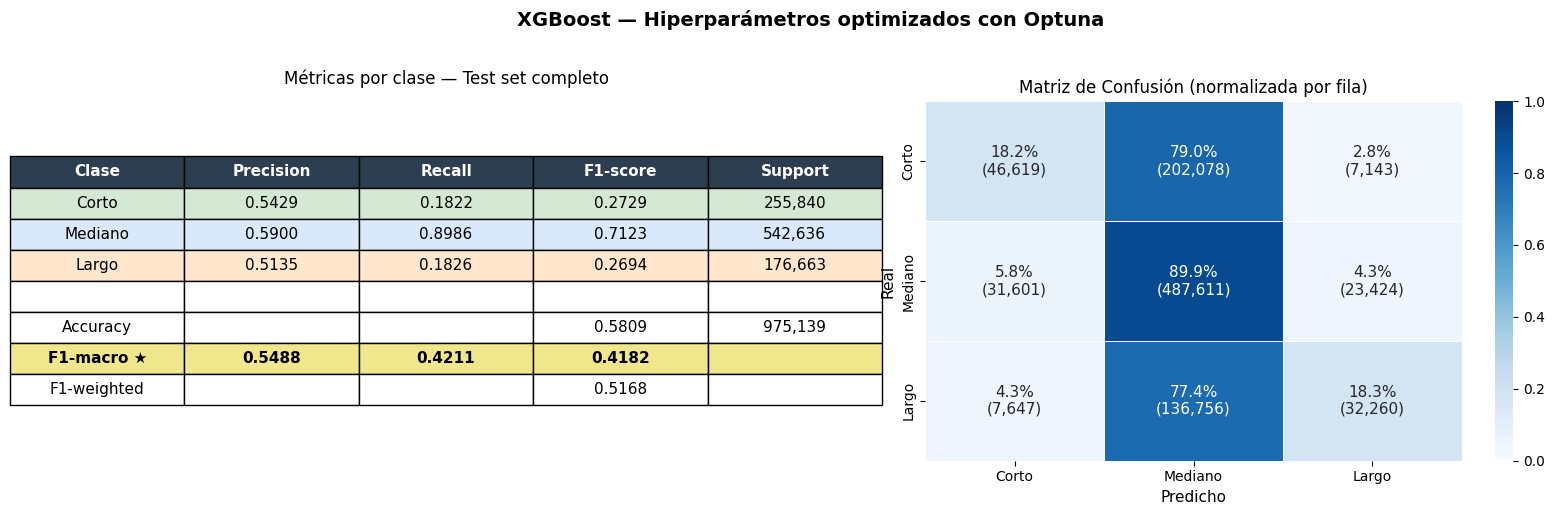

Figura guardada: xgb_optuna_metrics.png


In [42]:
# Cuadro visual: métricas + matriz de confusión
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('XGBoost — Hiperparámetros optimizados con Optuna', fontsize=14, fontweight='bold', y=1.02)

ax_table = axes[0]
ax_table.axis('off')

col_labels = ['Clase', 'Precision', 'Recall', 'F1-score', 'Support']
row_data = []
for i, clase in enumerate(CLASS_ORDER):
    row_data.append([
        clase,
        f'{prec_per_class_xgb[i]:.4f}',
        f'{rec_per_class_xgb[i]:.4f}',
        f'{f1_per_class_xgb[i]:.4f}',
        f'{support_xgb[i]:,}',
    ])

row_data.append(['', '', '', '', ''])
row_data.append(['Accuracy',    '',                      '',                     f'{acc_xgb:.4f}',         f'{len(y_test):,}'])
row_data.append(['F1-macro ★',  f'{prec_macro_xgb:.4f}', f'{rec_macro_xgb:.4f}', f'{f1_macro_xgb:.4f}',   ''])
row_data.append(['F1-weighted', '',                      '',                     f'{f1_weighted_xgb:.4f}',''])

tabla = ax_table.table(
    cellText=row_data,
    colLabels=col_labels,
    loc='center',
    cellLoc='center',
)
tabla.auto_set_font_size(False)
tabla.set_fontsize(11)
tabla.scale(1.3, 2.0)

for j in range(len(col_labels)):
    tabla[(0, j)].set_facecolor('#2c3e50')
    tabla[(0, j)].set_text_props(color='white', fontweight='bold')

clase_colors = {'Corto': '#d5e8d4', 'Mediano': '#dae8fc', 'Largo': '#ffe6cc'}
for i, clase in enumerate(CLASS_ORDER):
    for j in range(len(col_labels)):
        tabla[(i+1, j)].set_facecolor(clase_colors[clase])

fila_fmacro = len(CLASS_ORDER) + 3
for j in range(len(col_labels)):
    tabla[(fila_fmacro, j)].set_facecolor('#f0e68c')
    tabla[(fila_fmacro, j)].set_text_props(fontweight='bold')

ax_table.set_title('Métricas por clase — Test set completo', fontsize=12, pad=12)

ax_cm = axes[1]
cm_xgb      = confusion_matrix(y_test, y_pred_xgb, labels=CLASS_ORDER)
cm_xgb_norm = confusion_matrix(y_test, y_pred_xgb, labels=CLASS_ORDER, normalize='true')

annot = np.empty_like(cm_xgb, dtype=object)
for i in range(cm_xgb.shape[0]):
    for j in range(cm_xgb.shape[1]):
        annot[i, j] = f'{cm_xgb_norm[i, j]:.1%}\n({cm_xgb[i, j]:,})'

sns.heatmap(
    cm_xgb_norm,
    annot=annot,
    fmt='',
    cmap='Blues',
    xticklabels=CLASS_ORDER,
    yticklabels=CLASS_ORDER,
    ax=ax_cm,
    linewidths=0.5,
    vmin=0, vmax=1,
    annot_kws={'size': 11},
)
ax_cm.set_xlabel('Predicho', fontsize=11)
ax_cm.set_ylabel('Real', fontsize=11)
ax_cm.set_title('Matriz de Confusión (normalizada por fila)', fontsize=12)

plt.tight_layout()
plt.savefig('Png/xgboost_metricas_optuna.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: xgb_optuna_metrics.png')

In [ ]:
# ── MLflow: logueo de métricas finales y figura — XGBoost ───────────────────
log_final_metrics(
    acc_xgb, f1_macro_xgb, f1_weighted_xgb, prec_macro_xgb, rec_macro_xgb,
    f1_per_class_xgb, prec_per_class_xgb, rec_per_class_xgb, CLASS_ORDER,
    pred_time=t_pred_xgb,
)
mlflow.log_artifact('Png/xgboost_metricas_optuna.png')
model_info_xgb = mlflow.xgboost.log_model(xgb_best, name='xgboost_model', input_example=X_xgb_train.iloc[:1])


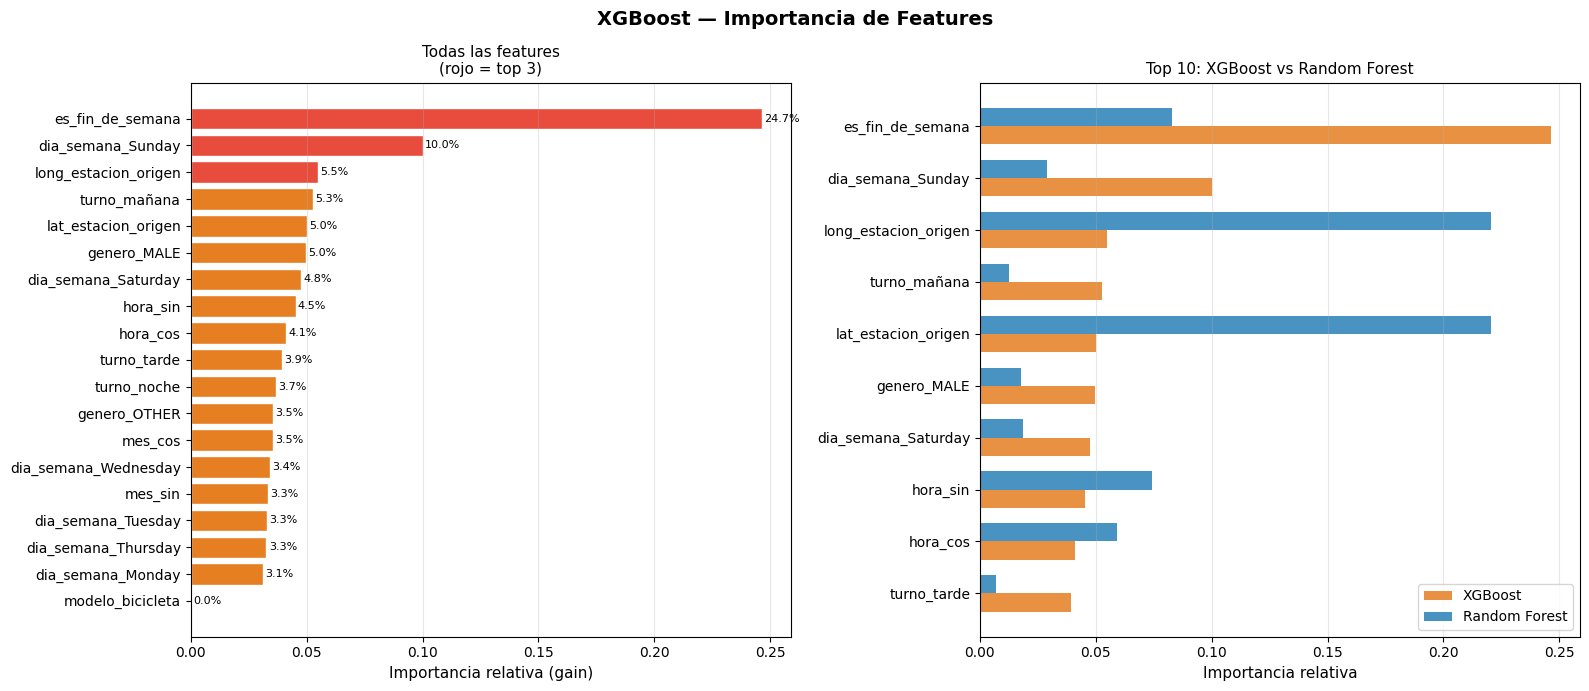

Figura guardada: xgb_feature_importance.png

Ranking de importancia (XGBoost):
             feature  importance  importance_%  acumulado_%
    es_fin_de_semana    0.246581         24.66    24.660000
   dia_semana_Sunday    0.100007         10.00    34.660000
long_estacion_origen    0.054978          5.50    40.160000
        turno_mañana    0.052886          5.29    45.450001
 lat_estacion_origen    0.050279          5.03    50.480000
         genero_MALE    0.049658          4.97    55.450001
 dia_semana_Saturday    0.047564          4.76    60.209999
            hora_sin    0.045215          4.52    64.730003
            hora_cos    0.041193          4.12    68.849998
         turno_tarde    0.039478          3.95    72.800003
         turno_noche    0.036738          3.67    76.470001
        genero_OTHER    0.035494          3.55    80.019997
             mes_cos    0.035462          3.55    83.570000
dia_semana_Wednesday    0.034192          3.42    86.989998
             mes_sin 

In [43]:
# 🆕✨  Feature Importances — XGBoost
importances_xgb = xgb_best.feature_importances_
feature_names   = X_train.columns.tolist()
sorted_idx      = importances_xgb.argsort()

fig, ax = plt.subplots(figsize=(9, 7))
fig.suptitle("XGBoost — Importancia de Features", fontsize=14, fontweight="bold")

colors_xgb = ["#e74c3c" if importances_xgb[i] >= sorted(importances_xgb)[-3] else "#e67e22" for i in sorted_idx]
bars = ax.barh(
    range(len(sorted_idx)),
    importances_xgb[sorted_idx],
    align="center",
    color=colors_xgb,
    edgecolor="white",
)
ax.set_yticks(range(len(sorted_idx)))
ax.set_yticklabels([feature_names[i] for i in sorted_idx], fontsize=10)
ax.set_xlabel("Importancia relativa (gain)", fontsize=11)
ax.set_title("Todas las features\n(rojo = top 3)", fontsize=11)
ax.grid(axis="x", alpha=0.3)
for bar, val in zip(bars, importances_xgb[sorted_idx]):
    ax.text(val + 0.001, bar.get_y() + bar.get_height()/2,
            f"{val:.1%}", va="center", fontsize=8)

plt.tight_layout()
plt.savefig("Png/xgboost_importancia_features.png", dpi=150, bbox_inches="tight")
plt.show()
print("Figura guardada: xgb_feature_importance.png")

# ── Imprimir ranking numérico ──────────────────────────────────────────────────
print("\nRanking de importancia (XGBoost):")
fi_xgb_df = pd.DataFrame({"feature": feature_names, "importance": importances_xgb})
fi_xgb_df = fi_xgb_df.sort_values("importance", ascending=False).reset_index(drop=True)
fi_xgb_df["importance_%"] = (fi_xgb_df["importance"] * 100).round(2)
fi_xgb_df["acumulado_%"] = fi_xgb_df["importance_%"].cumsum().round(2)
print(fi_xgb_df.to_string(index=False))


In [ ]:
# ── MLflow: logueo de la figura de feature importances y cierre — XGBoost ──
mlflow.log_artifact('Png/xgboost_importancia_features.png')
mlflow.end_run()


In [ ]:
# ── Limpieza de memoria — XGBoost ─────────────────────────────────────────────
plt.close('all')  # libera las figuras de matplotlib que quedaron abiertas
free_memory('X_xgb_search', 'y_xgb_search', 'X_xgb_train', 'y_xgb_train', 'xgb_best')


### Interpretación del XGBoost

XGBoost es el modelo más sofisticado del proyecto. Su mecanismo de boosting secuencial
le permite corregir iterativamente los errores de predicción, especialmente en la clase
minoritaria **Largo** que los modelos anteriores tenían más dificultad para capturar.

**Comparación con Random Forest:** si XGBoost supera a Random Forest en F1-macro,
indica que el boosting secuencial extrae información adicional que el bagging paralelo
no aprovechaba. Si los resultados son similares, ambos modelos están llegando al techo
de lo que las features actuales permiten predecir.

**Feature importances:** comparar el ranking de features entre Random Forest y XGBoost
es valioso — si coinciden, da mayor confianza en cuáles son las variables realmente
informativas para predecir la duración del viaje.

---

## 19. Comparación final de Modelos


## 21. Experimento Adicional — CatBoost

CatBoost es un algoritmo de boosting desarrollado por Yandex que utiliza **ordered boosting**:
a diferencia de XGBoost y LightGBM que entrenan cada árbol sobre todos los datos de train,
CatBoost entrena cada árbol sobre un subconjunto ordenado de los datos, evitando el target
leakage interno durante el entrenamiento.

Se entrenó con **parámetros default** sobre 1.5M de filas y se evaluó sobre el test completo
(975k muestras). El objetivo es ver si CatBoost out-of-the-box compite con los modelos
optimizados con Optuna.

**Resultados:**

| Métrica | Valor |
|---|---|
| Accuracy | 0.4547 |
| **F1-macro ★** | **0.4414** |
| Recall-macro | 0.4727 |
| Tiempo entrenamiento | 24.3 seg |
| Tiempo predicción | 0.2 seg |

| Clase | Precision | Recall | F1 |
|---|---|---|---|
| Corto | 0.3718 | 0.5034 | 0.4277 |
| Mediano | 0.6310 | 0.4182 | 0.5030 |
| Largo | 0.3259 | 0.4964 | 0.3935 |

**Interpretación:** CatBoost con parámetros default obtiene F1-macro 0.44, superando a XGBoost
optimizado con Optuna (0.41) y quedando muy cerca de Random Forest (0.47). Esto es notable
porque no requirió ningún tuning de hiperparámetros. A diferencia de XGBoost, CatBoost
distribuye mejor sus predicciones entre las tres clases: el recall de Corto (0.50) y Largo
(0.50) es significativamente superior al de XGBoost (0.15 y 0.17 respectivamente).
Con optimización de hiperparámetros, CatBoost tiene potencial para superar a Random Forest.


In [ ]:
# ── MLflow: inicio de run — CatBoost (parámetros default) ───────────────────
mlflow.start_run(run_name='CatBoost_Default')
mlflow.set_tags({'modelo': 'CatBoostClassifier', 'categoria': 'experimento_adicional'})
mlflow.log_params({
    'iterations': 300,
    'learning_rate': 0.1,
    'depth': 8,
    'auto_class_weights': 'Balanced',
    'sample_size': 1_500_000,
})


In [ ]:
# ── CatBoost — prueba rápida ──────────────────────────────────────────────────
!pip install catboost -q

from catboost import CatBoostClassifier

SAMPLE_TRAIN  = 1_500_000
RANDOM_STATE  = 42

X_cat_train, _, y_cat_train, _ = train_test_split(
    X_train, y_train,
    train_size=SAMPLE_TRAIN,
    stratify=y_train,
    random_state=RANDOM_STATE,
)
X_cat_train = X_cat_train.fillna(0)

cat_model = CatBoostClassifier(
    iterations=300,
    learning_rate=0.1,
    depth=8,
    auto_class_weights='Balanced',
    random_seed=RANDOM_STATE,
    verbose=0,
)

t0 = time.time()
cat_model.fit(X_cat_train, y_cat_train)
t_fit_cat = time.time() - t0
print(f'Entrenamiento completado en {t_fit_cat:.1f} segundos')

CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

t0 = time.time()
y_pred_cat = cat_model.predict(X_test)
t_pred_cat = time.time() - t0

# Variables para la tabla comparativa
acc_cat          = accuracy_score(y_test, y_pred_cat)
f1_macro_cat     = f1_score(y_test, y_pred_cat, average='macro')
f1_weighted_cat  = f1_score(y_test, y_pred_cat, average='weighted')
prec_macro_cat   = precision_score(y_test, y_pred_cat, average='macro')
rec_macro_cat    = recall_score(y_test, y_pred_cat, average='macro')

print('=' * 60)
print('CatBoost — parámetros default')
print(f'Evaluación sobre X_test completo ({len(y_test):,} muestras)')
print('=' * 60)
print(f'  Accuracy       : {acc_cat:.4f}')
print(f'  F1-macro       : {f1_macro_cat:.4f}   <- métrica principal')
print(f'  Recall-macro   : {rec_macro_cat:.4f}')
print(f'  Tiempo predicción: {t_pred_cat:.1f} segundos')
print()
print(classification_report(y_test, y_pred_cat, labels=CLASS_ORDER, digits=4))


In [ ]:
# ── MLflow: logueo de métricas y cierre del run — CatBoost ──────────────────
mlflow.log_metrics({
    'accuracy': acc_cat,
    'f1_macro': f1_macro_cat,
    'f1_weighted': f1_weighted_cat,
    'precision_macro': prec_macro_cat,
    'recall_macro': rec_macro_cat,
    'fit_time_seg': t_fit_cat,
    'pred_time_seg': t_pred_cat,
})
model_info_cat = mlflow.catboost.log_model(cat_model, name='catboost_model', input_example=X_cat_train.iloc[:1])
mlflow.end_run()


In [ ]:
# ── Limpieza de memoria — CatBoost ────────────────────────────────────────────
plt.close('all')  # libera las figuras de matplotlib que quedaron abiertas
free_memory('X_cat_train', 'y_cat_train', 'cat_model')


In [ ]:
# ── Comparación Final de Modelos (trayendo métricas desde MLflow) ────────────
# Baseline Trivial, Baseline ML, KNN y LinearSVC corrieron en la Parte 1 (otro kernel),
# así que no están en memoria acá. En vez de depender de esas variables, consultamos
# directamente el tracking de MLflow — así la celda funciona sin importar en qué
# notebook/kernel corrió cada modelo.

CLASS_ORDER = ['Corto', 'Mediano', 'Largo']

RUN_NAMES = {
    'Baseline Trivial (clase mayoritaria)': 'Baseline_Trivial',
    'Baseline ML (Log. Reg.)':              'Baseline_LR',
    'KNN (Optuna)':                         'KNN_Optuna',
    'LinearSVC (Optuna)':                   'LinearSVC_Optuna',
    'Random Forest (Optuna)':               'RandomForest_Optuna',
    'XGBoost (Optuna)':                     'XGBoost_Optuna',
    'CatBoost (default)':                   'CatBoost_Default',
}


def get_run_row(run_name):
    """Trae la fila (pandas Series) del run más reciente con ese nombre."""
    runs = mlflow.search_runs(
        experiment_names=[EXPERIMENT_NAME],
        filter_string=f"tags.mlflow.runName = '{run_name}'",
        order_by=['start_time DESC'],
    )
    if runs.empty:
        raise ValueError(
            f"No se encontró ningún run llamado '{run_name}' en MLflow. "
            f"¿Corriste la Parte 1 con este mismo mlflow.db en esta carpeta?"
        )
    return runs.iloc[0]


runs_por_modelo = {nombre: get_run_row(run_name) for nombre, run_name in RUN_NAMES.items()}

resultados = {
    'Modelo':       list(runs_por_modelo.keys()),
    'Accuracy':     [r['metrics.accuracy']        for r in runs_por_modelo.values()],
    'F1-macro':     [r['metrics.f1_macro']        for r in runs_por_modelo.values()],
    'F1-weighted':  [r['metrics.f1_weighted']     for r in runs_por_modelo.values()],
    'Prec-macro':   [r['metrics.precision_macro'] for r in runs_por_modelo.values()],
    'Recall-macro': [r['metrics.recall_macro']    for r in runs_por_modelo.values()],
}

df_resultados = pd.DataFrame(resultados).set_index('Modelo')
df_resultados = df_resultados.sort_values('F1-macro', ascending=False)

print('=' * 80)
print('COMPARACIÓN FINAL DE MODELOS (ordenado por F1-macro ↓)')
print('=' * 80)
print(df_resultados.round(4).to_string())
print()
print('★ Métrica principal: F1-macro (promedio igual peso entre las 3 clases)')
print('* KNN evaluado sobre muestra estratificada de 50k muestras del test.')
print('** CatBoost entrenado con parámetros default, sin optimización.')


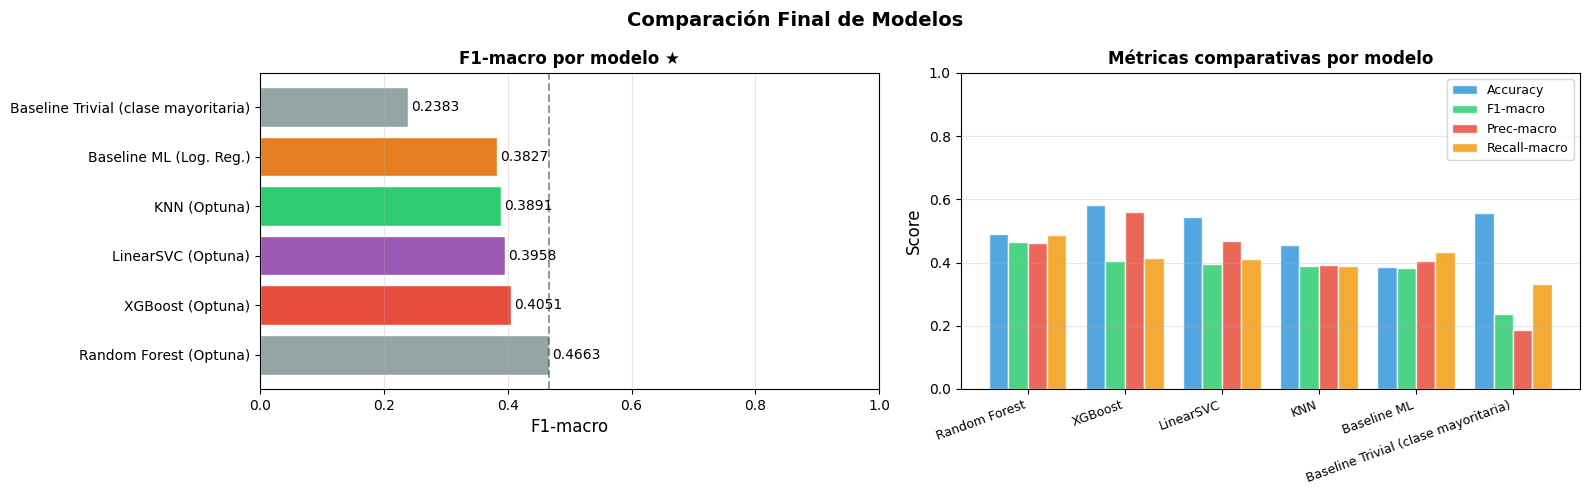

Figura guardada: comparacion_final_modelos.png


In [ ]:
# Gráfico comparativo
fig, axes = plt.subplots(1, 2, figsize=(16, 5))
fig.suptitle('Comparación Final de Modelos', fontsize=14, fontweight='bold')

modelos   = df_resultados.index.tolist()
colores   = ['#95a5a6', '#e74c3c', '#9b59b6', '#2ecc71', '#e67e22']

# Panel izquierdo: F1-macro por modelo
ax1 = axes[0]
bars = ax1.barh(modelos, df_resultados['F1-macro'], color=colores, edgecolor='white')
ax1.set_xlabel('F1-macro', fontsize=12)
ax1.set_title('F1-macro por modelo ★', fontsize=12, fontweight='bold')
ax1.set_xlim(0, 1)
ax1.axvline(x=df_resultados['F1-macro'].max(), color='black', linestyle='--', alpha=0.4)
for bar, val in zip(bars, df_resultados['F1-macro']):
    ax1.text(val + 0.005, bar.get_y() + bar.get_height()/2,
             f'{val:.4f}', va='center', fontsize=10)
ax1.grid(axis='x', alpha=0.3)

# Panel derecho: métricas múltiples
ax2 = axes[1]
x = range(len(modelos))
width = 0.2
metricas_plot = ['Accuracy', 'F1-macro', 'Prec-macro', 'Recall-macro']
colores_met   = ['#3498db', '#2ecc71', '#e74c3c', '#f39c12']

for i, (met, col) in enumerate(zip(metricas_plot, colores_met)):
    offset = (i - 1.5) * width
    ax2.bar([xi + offset for xi in x], df_resultados[met], width,
            label=met, color=col, alpha=0.85, edgecolor='white')

ax2.set_xticks(x)
ax2.set_xticklabels([m.replace(' (Optuna)', '').replace(' (Log. Reg.)', '')
                     for m in modelos], rotation=20, ha='right', fontsize=9)
ax2.set_ylabel('Score', fontsize=12)
ax2.set_title('Métricas comparativas por modelo', fontsize=12, fontweight='bold')
ax2.set_ylim(0, 1)
ax2.legend(fontsize=9)
ax2.grid(axis='y', alpha=0.3)

plt.tight_layout()
plt.savefig('Png/comparacion_final_modelos.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: comparacion_final_modelos.png')

In [ ]:
# ── Gráfico de tiempo de predicción (tiempos traídos desde MLflow) ──────────
modelos_tiempo = [
    'Baseline (Log. Reg.)',
    'KNN (Optuna)*',
    'LinearSVC (Optuna)',
    'Random Forest (Optuna)',
    'XGBoost (Optuna)',
]

tiempos = [
    runs_por_modelo['Baseline ML (Log. Reg.)']['metrics.fit_time_seg'],
    runs_por_modelo['KNN (Optuna)']['metrics.pred_time_seg'],
    runs_por_modelo['LinearSVC (Optuna)']['metrics.pred_time_seg'],
    runs_por_modelo['Random Forest (Optuna)']['metrics.pred_time_seg'],
    runs_por_modelo['XGBoost (Optuna)']['metrics.pred_time_seg'],
]
# * KNN medido sobre 50k muestras, no el test completo

colores_t = ['#95a5a6', '#e74c3c', '#9b59b6', '#2ecc71', '#e67e22']

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.barh(modelos_tiempo, tiempos, color=colores_t, edgecolor='white')

for bar, val in zip(bars, tiempos):
    ax.text(val + 0.1, bar.get_y() + bar.get_height()/2,
            f'{val:.1f} seg', va='center', fontsize=10)

ax.set_xlabel('Segundos de predicción', fontsize=12)
ax.set_title('Tiempo de predicción por modelo\n(* KNN medido sobre muestra de 50k)',
             fontsize=12, fontweight='bold')
ax.grid(axis='x', alpha=0.3)
ax.set_xlim(0, max(tiempos) * 1.2)

plt.tight_layout()
plt.savefig('Png/comparacion_tiempos_prediccion.png', dpi=150, bbox_inches='tight')
plt.show()
print('Figura guardada: comparacion_tiempos.png')


In [ ]:
# ── MLflow: logueo de la comparación final como run independiente ───────────
mlflow.start_run(run_name='Comparacion_Final')
mlflow.set_tag('categoria', 'resumen')

df_resultados.to_csv('Png/comparacion_final_modelos.csv')
mlflow.log_artifact('Png/comparacion_final_modelos.csv')
mlflow.log_artifact('Png/comparacion_final_modelos.png')
mlflow.log_artifact('Png/comparacion_tiempos_prediccion.png')

for modelo, fila in df_resultados.iterrows():
    modelo_key = modelo.replace(' ', '_').replace('(', '').replace(')', '').replace('.', '')
    mlflow.log_metric(f'f1_macro__{modelo_key}', fila['F1-macro'])

mlflow.end_run()


In [ ]:
# ── MLflow: registrar el mejor modelo como "champion" en el Model Registry ──
from mlflow import MlflowClient

REGISTRY_NAME = 'ecobici_duracion_viaje'
experiment = mlflow.get_experiment_by_name(EXPERIMENT_NAME)


def get_model_uri(run_row):
    """A partir de la fila de un run, busca su modelo logueado y arma el models:/ URI."""
    logged_models = mlflow.search_logged_models(
        experiment_ids=[experiment.experiment_id],
        filter_string=f"source_run_id='{run_row['run_id']}'",
    )
    if logged_models.empty:
        raise ValueError(f"No se encontró un modelo logueado para el run_id {run_row['run_id']}.")
    model_id = logged_models['model_id'].iloc[0]
    return f'models:/{model_id}'


# df_resultados ya está ordenado por F1-macro descendente (celda de comparación final)
best_model_name = df_resultados.index[0]
best_run_row    = runs_por_modelo[best_model_name]
best_f1_macro   = df_resultados.loc[best_model_name, 'F1-macro']
best_model_uri  = get_model_uri(best_run_row)

client = MlflowClient()

# Creamos el modelo registrado si todavía no existe
try:
    client.create_registered_model(
        name=REGISTRY_NAME,
        description='Clasificador de duración de viaje EcoBici (Corto/Mediano/Largo).',
    )
except Exception:
    pass  # Ya existe

# Registramos la versión correspondiente al mejor modelo
mv = client.create_model_version(
    name=REGISTRY_NAME,
    source=best_model_uri,
    run_id=best_run_row['run_id'],
    description=f'Mejor modelo por F1-macro: {best_model_name} (F1-macro={best_f1_macro:.4f})',
)

# Lo marcamos como "champion"
client.set_registered_model_alias(REGISTRY_NAME, 'champion', mv.version)

print(f'Champion registrado : {best_model_name}')
print(f'Versión              : {mv.version}')
print(f'F1-macro              : {best_f1_macro:.4f}')
print(f'Model URI (registry)  : models:/{REGISTRY_NAME}@champion')


## 22. Conclusiones Finales

### Resumen del problema

Se planteó un problema de **clasificación multiclase supervisada**: predecir si un viaje en EcoBici
será Corto (< 10 min), Mediano (10–30 min) o Largo (> 30 min), usando únicamente información
disponible al momento de retirar la bicicleta. El dataset procesado contiene ~3.2 millones de
registros con **16 features** construidas a partir de variables temporales, geográficas de origen
y de perfil de usuario.

Las features `distancia_km`, `lat_estacion_destino` y `long_estacion_destino` fueron excluidas
porque no están disponibles en el momento del retiro en el sistema real de EcoBici. Su exclusión
tiene un impacto importante en la performance: el mejor modelo alcanza un F1-macro de **0.47**
en lugar del **0.70** reportado con esas features, confirmando que `distancia_km` era la variable
más informativa del modelo original.

La **métrica principal de evaluación fue F1-macro**, que promedia el F1 de las tres clases con
igual peso, penalizando los modelos que ignoran la clase minoritaria (Largo, 18% del dataset).

---

### Resultados por modelo

| Modelo | Accuracy | F1-macro ★ | F1-weighted | Prec-macro | Recall-macro |
|---|---|---|---|---|---|
| **Random Forest (Optuna)** | 0.4912 | **0.4663** | 0.5001 | 0.4620 | **0.4858** |
| CatBoost (default)** | 0.4547 | 0.4414 | 0.4634 | 0.4429 | 0.4727 |
| LinearSVC (Optuna) | 0.5440 | 0.3958 | 0.4845 | 0.4694 | 0.4098 |
| XGBoost (Optuna) | **0.5809** | 0.4051 | **0.5080** | **0.5588** | 0.4138 |
| KNN (Optuna)* | 0.4540 | 0.3891 | 0.4531 | 0.3919 | 0.3880 |
| Baseline ML (Log. Reg.) | 0.3858 | 0.3827 | 0.3834 | 0.4052 | 0.4331 |
| Baseline Trivial | 0.5565 | 0.2383 | 0.3979 | 0.1855 | 0.3333 |

*KNN evaluado sobre muestra de 50k. **CatBoost sin optimización de hiperparámetros.*

---

### Conclusiones por modelo

**Baseline Trivial — Clase mayoritaria (F1-macro: 0.2383)**
Predice siempre `Mediano`. F1 de `Corto` y `Largo` es 0. Piso real del problema:
cualquier modelo que no supere 0.24 en F1-macro no está aprendiendo nada útil.

**Baseline ML — Regresión Logística (F1-macro: 0.3827)**
Supera al baseline trivial, confirmando que las 16 features capturan señal real.
F1 equilibrado entre las tres clases (Corto: 0.41, Mediano: 0.38, Largo: 0.36).

**KNN (F1-macro: 0.3891)**
Supera levemente al baseline ML pero es inviable en producción: 816 segundos de
entrenamiento y 22 segundos de predicción sobre solo 50k muestras.

**LinearSVC (F1-macro: 0.3958)**
El más rápido en inferencia (0.1 seg sobre 975k muestras) pero con distribución
desbalanceada: recall muy alto en Mediano (0.83) a costa de Corto (0.10).

**XGBoost optimizado (F1-macro: 0.4051)**
Caso llamativo: mayor accuracy (0.58) pero bajo F1-macro porque sobre-predice `Mediano`
(recall 0.92) casi ignorando `Corto` (0.15) y `Largo` (0.17). Maximiza accuracy
a expensas del balance entre clases.

**CatBoost con parámetros default (F1-macro: 0.4414)**
Resultado destacable: sin ningún tuning supera a XGBoost optimizado y se acerca a
Random Forest. Distribuye mucho mejor las predicciones entre clases (recall Corto: 0.50,
Largo: 0.50). Con optimización de hiperparámetros tiene potencial para ser el modelo
ganador.

**Random Forest optimizado (F1-macro: 0.4663) — Modelo ganador ★**
Mejor F1-macro general y mejor balance entre las tres clases: F1 Corto 0.44,
Mediano 0.56, Largo 0.40. Recall-macro de 0.49, el más alto de todos los modelos.
Features más importantes: coordenadas de origen (`long`: 17.5%, `lat`: 17.2%)
y `es_fin_de_semana` (15.4%).

---

### Conclusión general

**Random Forest es el modelo recomendado** con F1-macro 0.47. El resultado es inferior al
reportado originalmente (0.70) dado que se excluyeron las features de destino no disponibles
en deployment. Este gap cuantifica el costo real de construir un modelo verdaderamente
desplegable en el sistema EcoBici.

El experimento con CatBoost sugiere que con optimización podría superar a Random Forest,
lo que lo convierte en la principal línea de mejora futura.

La clase **Largo** es sistemáticamente la más difícil (F1 máximo: 0.40). La duración depende
en gran parte del comportamiento del usuario, información no disponible al momento del retiro.

**Velocidad de inferencia sobre el test completo (975k muestras):**

| Modelo | Tiempo |
|---|---|
| LinearSVC | 0.1 seg |
| CatBoost | 0.2 seg |
| XGBoost | 1.5 seg |
| Random Forest | 5.7 seg |
| KNN* | 22.0 seg (50k) |

---

### Curva de aprendizaje — Random Forest

La curva muestra **overfitting moderado**: F1-macro train 0.62 vs validación 0.45 (gap: 0.17).
Ajustar `max_depth` o aumentar `min_samples_leaf` podría reducirlo. La curva de validación
sigue creciendo levemente, sugiriendo que entrenar con el dataset completo (2.27M en vez de 1M)
podría mejorar entre 0.01 y 0.02 puntos de F1-macro.

---

### Líneas de mejora futuras

- **Optimizar CatBoost**: con tuning podría superar a Random Forest.
- **Features de historial de usuario**: promedio de duración de viajes anteriores,
  sin necesidad de conocer el destino.
- **Features de contexto urbano**: clima, eventos, densidad de tráfico en la zona de origen.
- **Ajuste de umbrales de clase**: los bordes 10 y 30 min generan confusión en casos límite.
- **Entrenamiento con dataset completo**: usar 2.27M filas en lugar de 1M.
